In [ ]:
import re
import pandas as pd

def func(s):
    if not isinstance(s, str):
        return []  # Return empty list for non-string inputs
    
    dict_pattern = r'\{[^}]+\}'
    dict_matches = re.findall(dict_pattern, s)
    kv_pattern = r"'([^']+)':\s([^,}]+)"
    extracted_data = []

    for dict_str in dict_matches:  # Limit to first 10 dictionaries
        kv_matches = re.findall(kv_pattern, dict_str)
        extracted_dict = {key: value.strip() for key, value in kv_matches}
        extracted_data.append(extracted_dict)
    
    return extracted_data
result = []
# Read the CSV in chunks
chunk_size = 10000  # Adjust this based on your available memory
for chunk in pd.read_csv(r"C:\Personal\Capstone project\Capstone project\final_ds_with_filenames.csv", chunksize=chunk_size):
    chunk["prev_72h_weather"] = chunk['prev_72h_weather'].progress_progress_progress_apply(func)
    result.append(chunk)
    # Process or save the chunk here
    print("Processed chunk")
merged_df = pd.concat(result, ignore_index=True)
print("All chunks processed")


Processed chunk
Processed chunk
Processed chunk
Processed chunk
All chunks processed


In [26]:
merged_df["prev_72h_weather"]

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
         ..
35132   NaN
35133   NaN
35134   NaN
35135   NaN
35136   NaN
Name: prev_72h_weather, Length: 35137, dtype: float64

In [ ]:
import tqdm

tqdm.tqdm.pandas()
def expand_weather_data(row):
    weather_data = row['prev_72h_weather']
    for key in weather_data[0].keys():
        if key != 'date':
            row[f'prev_72h_{key}'] = [entry[key] for entry in weather_data]
    return row

merged_df = merged_df.progress_progress_apply(expand_weather_data, axis=1)


100%|██████████| 35137/35137 [09:44<00:00, 60.12it/s]  


In [3]:
merged_df.to_csv("merged_df.csv", index=False)

In [ ]:
import ast

def clean_and_filter_layers(df, column_name='filename'):
    # Step 1: Convert string representation of list to actual list if needed
    def parse_if_string(x):
        if isinstance(x, str):
            try:
                return ast.literal_eval(x)
            except:
                return x
        return x
    
    # Apply parsing if the column contains string representations of lists
    df[column_name] = df[column_name].progress_progress_apply(parse_if_string)
    
    # Step 2: Filter for specific layers
    patterns = [
        'VIIRS_SNPP_Cirrus_Reflectance_SWIR_M11',
        'VIIRS_SNPP_Cirrus_Reflectance_VIS_NIR',
        'MODIS_Terra_CorrectedReflectance_TrueColor'
    ]
    
    # If the column contains lists, we need to filter elements within each list
    def filter_specific_layers(file_list):
        if isinstance(file_list, list):
            return [f for f in file_list if any(pattern in f for pattern in patterns)]
        return file_list
    
    df[column_name] = df[column_name].progress_progress_apply(filter_specific_layers)
    
    # Remove rows where the filtered list is empty
    df = df[df[column_name].progress_apply(lambda x: len(x) > 0 if isinstance(x, list) else True)]
    
    return df

merged_df = clean_and_filter_layers(merged_df, column_name='filenames')

100%|██████████| 35137/35137 [00:00<00:00, 800187.10it/s]


In [23]:
import numpy as np
import pandas as pd
from scipy import stats
import datetime as dt
from sklearn.preprocessing import StandardScaler

tqdm.pandas()
def convert_lists_to_arrays(df):
    """Convert string representations of lists to actual numpy arrays."""
    weather_columns = [col for col in df.columns if 'prev_72h_' in col]
    
    for col in weather_columns:
        if isinstance(df[col].iloc[0], str):
            df[col] = df[col].apply(lambda x: np.array(eval(x)) if isinstance(x, str) else np.array(x))
    
    return df

def extract_statistical_features(df):
    """Extract basic statistical features from the weather time series data."""
    weather_columns = [col for col in df.columns if 'prev_72h_' in col and col != 'prev_72h_weather']
    result_df = df.copy()
    
    for col in weather_columns:
        base_name = col.replace('prev_72h_', '')
        
        # Basic statistics
        result_df[f'{base_name}_mean'] = df[col].progress_apply(lambda x: np.mean(x) if not np.all(np.isnan(x)) else np.nan)
        
        result_df[f'{base_name}_median'] = df[col].apply(lambda x: np.median(x) if not np.all(np.isnan(x)) else np.nan)
        result_df[f'{base_name}_min'] = df[col].progress_apply(lambda x: np.min(x) if not np.all(np.isnan(x)) else np.nan)
        result_df[f'{base_name}_max'] = df[col].apply(lambda x: np.max(x) if not np.all(np.isnan(x)) else np.nan)
        result_df[f'{base_name}_range'] = df[col].apply(lambda x: np.ptp(x) if not np.all(np.isnan(x)) else np.nan)
        result_df[f'{base_name}_std'] = df[col].apply(lambda x: np.std(x) if not np.all(np.isnan(x)) else np.nan)
        result_df[f'{base_name}_var'] = df[col].apply(lambda x: np.var(x) if not np.all(np.isnan(x)) else np.nan)
        
        # Percentiles
        result_df[f'{base_name}_q25'] = df[col].apply(lambda x: np.percentile(x, 25) if not np.all(np.isnan(x)) else np.nan)
        result_df[f'{base_name}_q75'] = df[col].apply(lambda x: np.percentile(x, 75) if not np.all(np.isnan(x)) else np.nan)
        result_df[f'{base_name}_iqr'] = result_df[f'{base_name}_q75'] - result_df[f'{base_name}_q25']
        
        # Last values (most recent measurements)
        result_df[f'{base_name}_last_1h'] = df[col].apply(lambda x: x[-1] if len(x) > 0 and not np.isnan(x[-1]) else np.nan)
        result_df[f'{base_name}_last_3h_mean'] = df[col].apply(lambda x: np.mean(x[-3:]) if len(x) >= 3 and not np.all(np.isnan(x[-3:])) else np.nan)
        result_df[f'{base_name}_last_6h_mean'] = df[col].apply(lambda x: np.mean(x[-6:]) if len(x) >= 6 and not np.all(np.isnan(x[-6:])) else np.nan)
        result_df[f'{base_name}_last_12h_mean'] = df[col].apply(lambda x: np.mean(x[-12:]) if len(x) >= 12 and not np.all(np.isnan(x[-12:])) else np.nan)
        result_df[f'{base_name}_last_24h_mean'] = df[col].apply(lambda x: np.mean(x[-24:]) if len(x) >= 24 and not np.all(np.isnan(x[-24:])) else np.nan)
    
    return result_df

def extract_trend_features(df):
    """Extract trend-based features from the weather time series data."""
    weather_columns = [col for col in df.columns if 'prev_72h_' in col and col != 'prev_72h_weather']
    result_df = df.copy()
    
    for col in weather_columns:
        base_name = col.replace('prev_72h_', '')
        
        # Linear trend (slope)
        def calc_trend(x):
            x = np.asarray(x)
            if np.all(np.isnan(x)):
                return np.nan
            y = x[~np.isnan(x)]
            if len(y) < 2:
                return np.nan
            x_indices = np.arange(len(y))
            slope, _, _, _, _ = stats.linregress(x_indices, y)
            return slope
        
        result_df[f'{base_name}_trend_72h'] = df[col].apply(calc_trend)
        
        # Recent trends
        result_df[f'{base_name}_trend_24h'] = df[col].apply(lambda x: calc_trend(x[-24:]) if len(x) >= 24 else np.nan)
        result_df[f'{base_name}_trend_12h'] = df[col].apply(lambda x: calc_trend(x[-12:]) if len(x) >= 12 else np.nan)
        result_df[f'{base_name}_trend_6h'] = df[col].apply(lambda x: calc_trend(x[-6:]) if len(x) >= 6 else np.nan)
        
        # Rate of change
        result_df[f'{base_name}_rate_of_change'] = df[col].apply(
            lambda x: (x[-1] - x[0]) / len(x) if len(x) > 1 and not np.isnan(x[-1]) and not np.isnan(x[0]) else np.nan
        )
        
        # Acceleration (change in rate of change)
        def calc_acceleration(x):
            if len(x) < 3 or np.isnan(x[-1]) or np.isnan(x[-2]) or np.isnan(x[1]) or np.isnan(x[0]):
                return np.nan
            recent_change = x[-1] - x[-2]
            earlier_change = x[1] - x[0]
            return recent_change - earlier_change
        
        result_df[f'{base_name}_acceleration'] = df[col].apply(calc_acceleration)
    
    return result_df

def extract_volatility_features(df):
    """Extract volatility and variation features from the weather time series data."""
    weather_columns = [col for col in df.columns if 'prev_72h_' in col and col != 'prev_72h_weather']
    result_df = df.copy()
    
    for col in weather_columns:
        base_name = col.replace('prev_72h_', '')
        
        # Coefficient of variation
        result_df[f'{base_name}_cv'] = df[col].apply(
            lambda x: np.std(x) / np.mean(x) if not np.all(np.isnan(x)) and np.mean(x) != 0 else np.nan
        )
        
        # Number of peaks (local maxima)
        def count_peaks(x):
            if len(x) < 3 or np.all(np.isnan(x)):
                return np.nan
            return sum((x[i-1] < x[i] and x[i] > x[i+1]) for i in range(1, len(x)-1) if not np.isnan(x[i-1]) and not np.isnan(x[i]) and not np.isnan(x[i+1]))
        
        result_df[f'{base_name}_peak_count'] = df[col].apply(count_peaks)
        
        # Mean absolute change
        def mean_abs_change(x):
            if len(x) < 2 or np.all(np.isnan(x)):
                return np.nan
            diffs = np.diff(x)
            return np.mean(np.abs(diffs[~np.isnan(diffs)])) if len(diffs[~np.isnan(diffs)]) > 0 else np.nan
        
        result_df[f'{base_name}_mean_abs_change'] = df[col].apply(mean_abs_change)
        
        # Max absolute change
        def max_abs_change(x):
            if len(x) < 2 or np.all(np.isnan(x)):
                return np.nan
            diffs = np.diff(x)
            return np.max(np.abs(diffs[~np.isnan(diffs)])) if len(diffs[~np.isnan(diffs)]) > 0 else np.nan
        
        result_df[f'{base_name}_max_abs_change'] = df[col].apply(max_abs_change)
    
    return result_df

def extract_threshold_features(df):
    """Extract threshold-based features relevant to extreme weather."""
    result_df = df.copy()
    
    # Temperature extremes
    if 'prev_72h_temperature_2m' in df.columns:
        result_df['temp_hours_above_30C'] = df['prev_72h_temperature_2m'].apply(
            lambda x: np.sum(np.array(x) > 30) if not np.all(np.isnan(x)) else np.nan
        )
        result_df['temp_hours_below_0C'] = df['prev_72h_temperature_2m'].apply(
            lambda x: np.sum(np.array(x) < 0) if not np.all(np.isnan(x)) else np.nan
        )
        result_df['temp_consecutive_hours_above_30C'] = df['prev_72h_temperature_2m'].apply(
            lambda x: longest_consecutive_values(x, lambda val: val > 30) if not np.all(np.isnan(x)) else np.nan
        )
        result_df['temp_consecutive_hours_below_0C'] = df['prev_72h_temperature_2m'].apply(
            lambda x: longest_consecutive_values(x, lambda val: val < 0) if not np.all(np.isnan(x)) else np.nan
        )
    
    # Precipitation extremes
    if 'prev_72h_precipitation' in df.columns:
        result_df['precipitation_total'] = df['prev_72h_precipitation'].apply(
            lambda x: np.sum(x) if not np.all(np.isnan(x)) else np.nan
        )
        result_df['heavy_rain_hours'] = df['prev_72h_precipitation'].apply(
            lambda x: np.sum(np.array(x) > 10) if not np.all(np.isnan(x)) else np.nan  # >10mm/hour is heavy rain
        )
        result_df['consecutive_rain_hours'] = df['prev_72h_precipitation'].apply(
            lambda x: longest_consecutive_values(x, lambda val: val > 0) if not np.all(np.isnan(x)) else np.nan
        )
        
        # Intensity features
        result_df['max_3h_precipitation'] = df['prev_72h_precipitation'].apply(
            lambda x: max_window_sum(x, 3) if not np.all(np.isnan(x)) else np.nan
        )
        result_df['max_6h_precipitation'] = df['prev_72h_precipitation'].apply(
            lambda x: max_window_sum(x, 6) if not np.all(np.isnan(x)) else np.nan
        )
        result_df['max_12h_precipitation'] = df['prev_72h_precipitation'].apply(
            lambda x: max_window_sum(x, 12) if not np.all(np.isnan(x)) else np.nan
        )
        result_df['max_24h_precipitation'] = df['prev_72h_precipitation'].apply(
            lambda x: max_window_sum(x, 24) if not np.all(np.isnan(x)) else np.nan
        )
    
    # Wind extremes
    if 'prev_72h_wind_speed_10m' in df.columns:
        result_df['hours_with_strong_wind'] = df['prev_72h_wind_speed_10m'].apply(
            lambda x: np.sum(np.array(x) > 10.8) if not np.all(np.isnan(x)) else np.nan  # >10.8 m/s (Beaufort 6+)
        )
        result_df['hours_with_gale_wind'] = df['prev_72h_wind_speed_10m'].apply(
            lambda x: np.sum(np.array(x) > 17.2) if not np.all(np.isnan(x)) else np.nan  # >17.2 m/s (Beaufort 8+)
        )
        result_df['consecutive_strong_wind_hours'] = df['prev_72h_wind_speed_10m'].apply(
            lambda x: longest_consecutive_values(x, lambda val: val > 10.8) if not np.all(np.isnan(x)) else np.nan
        )
    
    # Humidity extremes
    if 'prev_72h_relative_humidity_2m' in df.columns:
        result_df['hours_with_high_humidity'] = df['prev_72h_relative_humidity_2m'].apply(
            lambda x: np.sum(np.array(x) > 90) if not np.all(np.isnan(x)) else np.nan
        )
        result_df['hours_with_low_humidity'] = df['prev_72h_relative_humidity_2m'].apply(
            lambda x: np.sum(np.array(x) < 30) if not np.all(np.isnan(x)) else np.nan
        )
    
    # Pressure systems
    if 'prev_72h_pressure_msl' in df.columns:
        result_df['pressure_drop'] = df['prev_72h_pressure_msl'].apply(
            lambda x: find_max_pressure_drop(x) if not np.all(np.isnan(x)) else np.nan
        )
        result_df['low_pressure_hours'] = df['prev_72h_pressure_msl'].apply(
            lambda x: np.sum(np.array(x) < 1000) if not np.all(np.isnan(x)) else np.nan
        )
    
    return result_df

def extract_derived_features(df):
    """Create derived features that combine multiple weather variables."""
    result_df = df.copy()
    
    # Heat index (if temperature and humidity available)
    if 'prev_72h_temperature_2m' in df.columns and 'prev_72h_relative_humidity_2m' in df.columns:
        result_df['heat_index_max'] = df.apply(
            lambda row: calculate_heat_index(
                np.array(row['prev_72h_temperature_2m']), 
                np.array(row['prev_72h_relative_humidity_2m'])
            ).max() if not np.all(np.isnan(row['prev_72h_temperature_2m'])) and not np.all(np.isnan(row['prev_72h_relative_humidity_2m'])) else np.nan,
            axis=1
        )
        
        result_df['heat_index_hours_above_32C'] = df.apply(
            lambda row: np.sum(calculate_heat_index(
                np.array(row['prev_72h_temperature_2m']), 
                np.array(row['prev_72h_relative_humidity_2m'])
            ) > 32) if not np.all(np.isnan(row['prev_72h_temperature_2m'])) and not np.all(np.isnan(row['prev_72h_relative_humidity_2m'])) else np.nan,
            axis=1
        )
    
    # Wind chill (if temperature and wind speed available)
    if 'prev_72h_temperature_2m' in df.columns and 'prev_72h_wind_speed_10m' in df.columns:
        result_df['wind_chill_min'] = df.apply(
            lambda row: calculate_wind_chill(
                np.array(row['prev_72h_temperature_2m']), 
                np.array(row['prev_72h_wind_speed_10m'])
            ).min() if not np.all(np.isnan(row['prev_72h_temperature_2m'])) and not np.all(np.isnan(row['prev_72h_wind_speed_10m'])) else np.nan,
            axis=1
        )
        
        result_df['extreme_cold_wind_chill_hours'] = df.apply(
            lambda row: np.sum(calculate_wind_chill(
                np.array(row['prev_72h_temperature_2m']), 
                np.array(row['prev_72h_wind_speed_10m'])
            ) < -15) if not np.all(np.isnan(row['prev_72h_temperature_2m'])) and not np.all(np.isnan(row['prev_72h_wind_speed_10m'])) else np.nan,
            axis=1
        )
    
    # Drought index (if temperature, precipitation, and evapotranspiration available)
    if all(col in df.columns for col in ['prev_72h_temperature_2m', 'prev_72h_precipitation', 'prev_72h_et0_fao_evapotranspiration']):
        result_df['simple_drought_index'] = df.apply(
            lambda row: calculate_simple_drought_index(
                np.array(row['prev_72h_precipitation']), 
                np.array(row['prev_72h_et0_fao_evapotranspiration'])
            ) if not np.all(np.isnan(row['prev_72h_precipitation'])) and not np.all(np.isnan(row['prev_72h_et0_fao_evapotranspiration'])) else np.nan,
            axis=1
        )
    
    # Flood potential index
    if 'prev_72h_precipitation' in df.columns and 'prev_72h_soil_moisture_0_to_7cm' in df.columns:
        result_df['flood_potential_index'] = df.apply(
            lambda row: calculate_flood_potential(
                np.array(row['prev_72h_precipitation']), 
                np.array(row['prev_72h_soil_moisture_0_to_7cm'])
            ) if not np.all(np.isnan(row['prev_72h_precipitation'])) and not np.all(np.isnan(row['prev_72h_soil_moisture_0_to_7cm'])) else np.nan,
            axis=1
        )
    

    return result_df

def extract_event_timing_features(df):
    """Extract features related to the timing of the event."""
    result_df = df.copy()
    
    # Convert event datetime to datetime object if it's not already
    if isinstance(result_df['event_datetime'].iloc[0], str):
        result_df['event_datetime'] = pd.to_datetime(result_df['event_datetime'])
    
    # Extract time-related features
    result_df['event_hour'] = result_df['event_datetime'].dt.hour
    result_df['event_day'] = result_df['event_datetime'].dt.day
    result_df['event_month'] = result_df['event_datetime'].dt.month
    result_df['event_dayofweek'] = result_df['event_datetime'].dt.dayofweek
    result_df['event_quarter'] = result_df['event_datetime'].dt.quarter
    result_df['event_is_weekend'] = result_df['event_dayofweek'].isin([5, 6]).astype(int)
    
    # Time of day categories
    result_df['event_time_of_day'] = pd.cut(
        result_df['event_hour'], 
        bins=[-1, 5, 11, 17, 23], 
        labels=['night', 'morning', 'afternoon', 'evening']
    )
    
    # Season (Northern Hemisphere)
    result_df['event_season'] = pd.cut(
        result_df['event_month'],
        bins=[0, 2, 5, 8, 11, 12],
        labels=['winter', 'spring', 'summer', 'fall', 'winter'],
        ordered=False
    )
    
    # Convert categorical features to dummy variables
    result_df = pd.get_dummies(result_df, columns=['event_time_of_day', 'event_season'], drop_first=True)
    
    return result_df


# Helper functions

def longest_consecutive_values(array, condition_func):
    """Find the longest streak of values that meet a condition."""
    if len(array) == 0:
        return 0
    
    current_streak = 0
    max_streak = 0
    
    for val in array:
        if np.isnan(val):
            current_streak = 0
            continue
            
        if condition_func(val):
            current_streak += 1
            max_streak = max(max_streak, current_streak)
        else:
            current_streak = 0
            
    return max_streak

def max_window_sum(array, window_size):
    """Find the maximum sum in a sliding window of specified size."""
    if len(array) < window_size:
        return np.sum(array)
    
    # Convert to numpy array to handle nan values properly
    arr = np.array(array)
    
    # Use convolution for sliding window sum
    window_sums = np.convolve(np.nan_to_num(arr, nan=0), np.ones(window_size), 'valid')
    return np.max(window_sums)

def find_max_pressure_drop(pressure_array):
    """Find the maximum pressure drop over any 24-hour period."""
    if len(pressure_array) <= 24:
        return np.max(pressure_array) - np.min(pressure_array)
    
    max_drop = 0
    for i in range(len(pressure_array) - 24):
        drop = pressure_array[i] - pressure_array[i + 24]
        max_drop = max(max_drop, drop)
    
    return max_drop

def calculate_heat_index(temperature_c, humidity):
    """Calculate heat index from temperature (°C) and relative humidity (%)."""
    # Convert to Fahrenheit for the standard heat index formula
    temperature_f = temperature_c * 9/5 + 32
    
    # Heat index calculation (Rothfusz regression)
    hi = 0.5 * (temperature_f + 61.0 + ((temperature_f - 68.0) * 1.2) + (humidity * 0.094))
    
    # For temperature_f >= 80, use more complex formula
    mask = temperature_f >= 80
    if np.any(mask):
        temp_masked = temperature_f[mask]
        hum_masked = humidity[mask]
        
        hi_masked = -42.379 + 2.04901523 * temp_masked + 10.14333127 * hum_masked \
                  - 0.22475541 * temp_masked * hum_masked - 6.83783e-3 * temp_masked**2 \
                  - 5.481717e-2 * hum_masked**2 + 1.22874e-3 * temp_masked**2 * hum_masked \
                  + 8.5282e-4 * temp_masked * hum_masked**2 - 1.99e-6 * temp_masked**2 * hum_masked**2
        
        if isinstance(hi, np.ndarray):
            hi[mask] = hi_masked
        else:
            hi = hi_masked
    
    # Convert back to Celsius
    return (hi - 32) * 5/9

def calculate_wind_chill(temperature_c, wind_speed_ms):
    """Calculate wind chill from temperature (°C) and wind speed (m/s)."""
    # Wind chill only applies when temp is below 10°C and wind speed is above 4.8 km/h
    wind_speed_kmh = wind_speed_ms * 3.6
    
    wind_chill = np.copy(temperature_c)
    mask = (temperature_c < 10) & (wind_speed_kmh > 4.8)
    
    if np.any(mask):
        # North American formula
        wind_chill[mask] = 13.12 + 0.6215 * temperature_c[mask] - 11.37 * wind_speed_kmh[mask]**0.16 + 0.3965 * temperature_c[mask] * wind_speed_kmh[mask]**0.16
    
    return wind_chill

def calculate_simple_drought_index(precipitation, evapotranspiration):
    """Calculate a simple drought index as precipitation minus evapotranspiration."""
    return np.sum(precipitation) - np.sum(evapotranspiration)

def calculate_flood_potential(precipitation, soil_moisture):
    """Calculate a simple flood potential index based on precipitation and soil moisture."""
    # Normalize inputs to 0-1 scale
    if np.max(precipitation) > 0:
        norm_precip = precipitation / max(np.max(precipitation), 1)
    else:
        norm_precip = precipitation
    
    if np.max(soil_moisture) > 0:
        norm_soil = soil_moisture / max(np.max(soil_moisture), 1)
    else:
        norm_soil = soil_moisture
    
    # Weight recent precipitation more heavily
    weights = np.linspace(0.5, 1.0, len(precipitation))
    weighted_precip = norm_precip * weights
    
    # Calculate flood potential (higher values indicate higher flood risk)
    return np.sum(weighted_precip) * np.mean(norm_soil)



In [4]:
merged_df

,event_type,begin_date_time,cz_timezone,end_date_time,begin_lat,begin_lon,end_lat,end_lon,extreme,begin_date_utc,...,prev_72h_wind_direction_100m,prev_72h_wind_gusts_10m,prev_72h_soil_temperature_0_to_7cm,prev_72h_soil_temperature_7_to_28cm,prev_72h_soil_temperature_28_to_100cm,prev_72h_soil_temperature_100_to_255cm,prev_72h_soil_moisture_0_to_7cm,prev_72h_soil_moisture_7_to_28cm,prev_72h_soil_moisture_28_to_100cm,prev_72h_soil_moisture_100_to_255cm
0,Flood,2012-10-29 12:30:00,EST-5,2012-10-29 22:30:00,37.84,-75.48,37.70,-75.62,0,2012-10-29,...,"[75.5559310913086, 77.90525817871094, 78.54128...","[30.96000099182129, 33.47999954223633, 34.2000...","[21.88249969482422, 21.932498931884766, 21.482...","[19.182498931884766, 19.38249969482422, 19.482...","[19.182498931884766, 19.182498931884766, 19.18...","[21.682498931884766, 21.682498931884766, 21.68...","[0.33799999952316284, 0.3370000123977661, 0.33...","[0.3540000021457672, 0.3529999852180481, 0.352...","[0.3330000042915344, 0.3319999873638153, 0.331...","[0.3449999988079071, 0.3449999988079071, 0.344..."
1,Heavy Rain,2014-05-15 14:00:00,EST-5,2014-05-16 17:00:00,37.84,-75.48,37.82,-75.62,0,2014-05-15,...,"[198.64962768554688, 193.87754821777344, 191.1...","[39.959999084472656, 40.68000030517578, 40.319...","[24.58249855041504, 24.38249969482422, 23.8824...","[19.58249855041504, 19.782499313354492, 19.932...","[14.982500076293945, 14.982500076293945, 15.03...","[9.782500267028809, 9.782500267028809, 9.78250...","[0.3240000009536743, 0.3230000138282776, 0.321...","[0.3479999899864197, 0.3479999899864197, 0.347...","[0.37299999594688416, 0.37299999594688416, 0.3...","[0.414000004529953, 0.414000004529953, 0.41400..."
2,Heavy Rain,2016-10-08 10:00:00,EST-5,2016-10-09 11:00:00,37.84,-75.48,37.84,-75.48,0,2016-10-08,...,"[55.645606994628906, 56.97612762451172, 57.002...","[47.15999984741211, 45.36000061035156, 44.6399...","[21.032499313354492, 21.782499313354492, 22.23...","[20.932498931884766, 21.032499313354492, 21.13...","[22.732500076293945, 22.732500076293945, 22.73...","[23.08249855041504, 23.08249855041504, 23.0824...","[0.38999998569488525, 0.3889999985694885, 0.38...","[0.4020000100135803, 0.4009999930858612, 0.400...","[0.3880000114440918, 0.3880000114440918, 0.388...","[0.37700000405311584, 0.37700000405311584, 0.3..."
3,Flash Flood,2014-09-21 23:14:00,MST-7,2014-09-22 02:00:00,32.90,-107.34,32.82,-107.34,0,2014-09-22,...,"[138.81417846679688, 270.0, 311.98712158203125...","[6.479999542236328, 5.399999618530273, 7.19999...","[19.298999786376953, 19.39900016784668, 19.249...","[21.39900016784668, 21.3489990234375, 21.24900...","[25.3489990234375, 25.3489990234375, 25.298999...","[26.198999404907227, 26.198999404907227, 26.19...","[0.3709999918937683, 0.36899998784065247, 0.36...","[0.3070000112056732, 0.3070000112056732, 0.307...","[0.15800000727176666, 0.15800000727176666, 0.1...","[0.15700000524520874, 0.15700000524520874, 0.1..."
4,Flash Flood,2014-09-27 16:00:00,MST-7,2014-09-27 23:00:00,39.70,-110.88,39.54,-110.92,1,2014-09-27,...,"[173.4803009033203, 169.69520568847656, 168.69...","[26.639999389648438, 24.119998931884766, 19.79...","[30.48900032043457, 28.388999938964844, 25.088...","[19.68899917602539, 19.93899917602539, 20.0889...","[19.48900032043457, 19.48900032043457, 19.4890...","[18.538999557495117, 18.538999557495117, 18.53...","[0.04800000041723251, 0.04699999839067459, 0.0...","[0.16099999845027924, 0.16099999845027924, 0.1...","[0.22300000488758087, 0.22300000488758087, 0.2...","[0.2590000033378601, 0.2590000033378601, 0.259..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35132,Flood,2012-09-09 23:30:00,MST-7,2012-09-13 08:30:00,31.96,-112.20,31.98,-112.36,0,2012-09-10,...,"[173.15731811523438, 167.90525817871094, 176.3...","[10.079999923706055, 9.359999656677246, 10.079...","[27.671001434326172, 27.121000289916992, 26.67...","[32.72100067138672, 32.520999908447266, 32.320...","[32.42100143432617, 32.421001434326

In [11]:
prev_cols = [col for col in merged_df.columns if col.startswith('prev_72h')]
prev_cols.remove('prev_72h_weather')
print(prev_cols)

['prev_72h_temperature_2m', 'prev_72h_relative_humidity_2m', 'prev_72h_dew_point_2m', 'prev_72h_apparent_temperature', 'prev_72h_precipitation', 'prev_72h_rain', 'prev_72h_snowfall', 'prev_72h_snow_depth', 'prev_72h_weather_code', 'prev_72h_pressure_msl', 'prev_72h_surface_pressure', 'prev_72h_cloud_cover', 'prev_72h_cloud_cover_low', 'prev_72h_cloud_cover_mid', 'prev_72h_cloud_cover_high', 'prev_72h_et0_fao_evapotranspiration', 'prev_72h_vapour_pressure_deficit', 'prev_72h_wind_speed_10m', 'prev_72h_wind_speed_100m', 'prev_72h_wind_direction_10m', 'prev_72h_wind_direction_100m', 'prev_72h_wind_gusts_10m', 'prev_72h_soil_temperature_0_to_7cm', 'prev_72h_soil_temperature_7_to_28cm', 'prev_72h_soil_temperature_28_to_100cm', 'prev_72h_soil_temperature_100_to_255cm', 'prev_72h_soil_moisture_0_to_7cm', 'prev_72h_soil_moisture_7_to_28cm', 'prev_72h_soil_moisture_28_to_100cm', 'prev_72h_soil_moisture_100_to_255cm']


In [13]:
merged_df = convert_lists_to_arrays(merged_df)
import ast
import numpy as np
import pandas as pd
from tqdm import tqdm

# Define a helper function to convert a string list to a list of floats
def convert_str_list_to_float_list(x):
    try:

        return [float(item) for item in x]
    except Exception as e:
        # In case conversion fails, return NaN (or you could choose to return x)
        print("conversion failed ", e)
        return np.nan

for col in tqdm(prev_cols):
    merged_df[col] = merged_df[col].apply(convert_str_list_to_float_list)


100%|██████████| 30/30 [23:42<00:00, 47.41s/it] 


In [ ]:

print("Conversion complete")
merged_df = extract_statistical_features(merged_df)
print("Statistical features extracted")
merged_df = extract_trend_features(merged_df)
print("Trend features extracted")
merged_df = extract_volatility_features(merged_df)
print("Volatility features extracted")
merged_df = extract_threshold_features(merged_df)
print("Threshold features extracted")
merged_df = extract_derived_features(merged_df)


Conversion complete


100%|██████████| 35137/35137 [00:00<00:00, 86514.89it/s]


Statistical features extracted


C:\Users\naman\AppData\Local\Temp\ipykernel_16644\1305693218.py:73: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result_df[f'{base_name}_trend_24h'] = df[col].apply(lambda x: calc_trend(x[-24:]) if len(x) >= 24 else np.nan)
C:\Users\naman\AppData\Local\Temp\ipykernel_16644\1305693218.py:74: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result_df[f'{base_name}_trend_12h'] = df[col].apply(lambda x: calc_trend(x[-12:]) if len(x) >= 12 else np.nan)
C:\Users\naman\AppData\Local\Temp\ipykernel_16644\1305693218.py:75: PerformanceWarni

Trend features extracted


C:\Users\naman\AppData\Local\Temp\ipykernel_16644\1305693218.py:113: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result_df[f'{base_name}_peak_count'] = df[col].apply(count_peaks)
C:\Users\naman\AppData\Local\Temp\ipykernel_16644\1305693218.py:122: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result_df[f'{base_name}_mean_abs_change'] = df[col].apply(mean_abs_change)
C:\Users\naman\AppData\Local\Temp\ipykernel_16644\1305693218.py:131: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `fr

Volatility features extracted
Threshold features extracted
Derived features extracted


ValueError: labels must be unique if ordered=True; pass ordered=False for duplicate labels

In [24]:
print("Derived features extracted")
merged_df = extract_event_timing_features(merged_df)


Derived features extracted


In [25]:
merged_df.to_csv("final_features.csv", index=False)

In [26]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35137 entries, 0 to 35136
Columns: 836 entries, event_type to event_season_winter
dtypes: bool(6), datetime64[ns, UTC](1), float64(736), int32(5), int64(47), object(41)
memory usage: 222.0+ MB


In [ ]:
for c in merged_df.columns:
    print(c)


event_type
begin_date_time
cz_timezone
end_date_time
begin_lat
begin_lon
end_lat
end_lon
extreme
begin_date_utc
begin_time_utc
end_date_utc
end_time_utc
cluster
start_date_72h
end_date
event_datetime
prev_72h_weather
event_id
filenames
prev_72h_temperature_2m
prev_72h_relative_humidity_2m
prev_72h_dew_point_2m
prev_72h_apparent_temperature
prev_72h_precipitation
prev_72h_rain
prev_72h_snowfall
prev_72h_snow_depth
prev_72h_weather_code
prev_72h_pressure_msl
prev_72h_surface_pressure
prev_72h_cloud_cover
prev_72h_cloud_cover_low
prev_72h_cloud_cover_mid
prev_72h_cloud_cover_high
prev_72h_et0_fao_evapotranspiration
prev_72h_vapour_pressure_deficit
prev_72h_wind_speed_10m
prev_72h_wind_speed_100m
prev_72h_wind_direction_10m
prev_72h_wind_direction_100m
prev_72h_wind_gusts_10m
prev_72h_soil_temperature_0_to_7cm
prev_72h_soil_temperature_7_to_28cm
prev_72h_soil_temperature_28_to_100cm
prev_72h_soil_temperature_100_to_255cm
prev_72h_soil_moisture_0_to_7cm
prev_72h_soil_moisture_7_to_28cm
prev

In [6]:
import pandas as pd
merged_df = pd.read_csv(r"final_features.csv")
cls_to_remove = [c for c in merged_df.columns if 'prev_72h_' in c]
other_cols_remove = ['event_type','begin_date_time','cz_timezone','end_date_time','begin_lat','begin_lon','end_lat','end_lon','begin_date_utc','begin_time_utc','end_date_utc','end_time_utc','cluster','start_date_72h','end_date','event_datetime','prev_72h_weather','event_id','filenames']
cls_to_remove.extend(other_cols_remove)
without_prev = merged_df.drop(columns=cls_to_remove)
print(without_prev)

C:\Users\naman\AppData\Local\Temp\ipykernel_27016\2449260679.py:2: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  merged_df = pd.read_csv(r"final_features.csv")


       extreme  temperature_2m_mean  temperature_2m_median  \
0            0            16.049861              15.682500   
1            0            20.804027              20.607499   
2            0            20.249166              20.332499   
3            0            21.503167              21.198999   
4            1            19.432750              18.939000   
...        ...                  ...                    ...   
35132        0            27.199473              26.921000   
35133        0            20.636862              19.682000   
35134        0            21.999611              21.313499   
35135        0            18.543500              17.343500   
35136        0            15.359667              13.980500   

       temperature_2m_min  temperature_2m_max  temperature_2m_range  \
0               12.032500           20.932499              8.899999   
1               16.232500           27.432499             11.199999   
2               18.382500           23.282

In [10]:
# Separate categorical and numerical columns more accurately
categorical_cols = []
numerical_cols = []

for col in without_prev.columns:
    # Check if column has less than 5% unique values
    is_low_cardinality = len(without_prev[col].unique())/len(without_prev[col]) < 0.05
    
    # Check if column is numeric
    is_numeric = pd.api.types.is_numeric_dtype(without_prev[col])
    
    if is_low_cardinality:
        if is_numeric:
            # For numeric columns with low cardinality, check if they're truly categorical
            # Option 1: Check if all values are integers or have no decimal part
            if without_prev[col].dropna().apply(lambda x: float(x).is_integer()).all():
                categorical_cols.append(col)
            else:
                numerical_cols.append(col)
        else:
            # Non-numeric columns with low cardinality are likely categorical
            categorical_cols.append(col)
    else:
        # High cardinality columns are likely not categorical
        if is_numeric:
            numerical_cols.append(col)
        else:
            # For non-numeric high cardinality, you might need to inspect
            # For now, assume they're categorical (like text fields)
            categorical_cols.append(col)

print(f"Categorical columns: {len(categorical_cols)}")
print(f"Numerical columns: {len(numerical_cols)}")
print(f"Total columns: {len(without_prev.columns)}")

Categorical columns: 88
Numerical columns: 695
Total columns: 783


(35137, 787)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35137 entries, 0 to 35136
Columns: 787 entries, extreme to event_season_winter
dtypes: bool(6), float64(731), int32(5), int64(45)
memory usage: 208.9 MB
None
                         count       mean       std        min        25%  \
extreme                35137.0   0.098443  0.297917   0.000000   0.000000   
temperature_2m_mean    35137.0  18.297422  7.743814 -20.820472  13.773667   
temperature_2m_median  35137.0  18.031668  7.647957 -21.301999  13.731500   
temperature_2m_min     35137.0  12.439272  8.895572 -31.214500   6.950500   
temperature_2m_max     35137.0  24.915315  7.384128 -19.242001  20.903999   
...                        ...        ...       ...        ...        ...   
event_day              35137.0  15.264052  8.923922   1.000000   8.000000   
event_month            35137.0   6.485016  2.812829   1.000000   5.000000   
event_dayofweek        35137.0   2.974358  1.935477   0.000000   1.000000   
event_qua

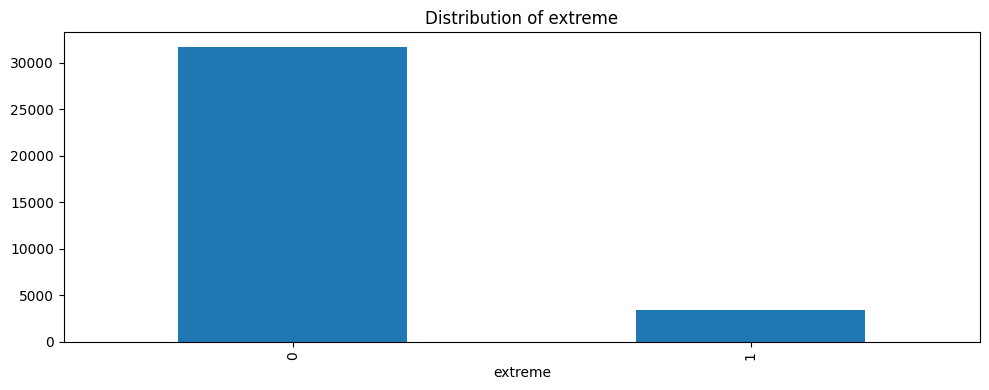

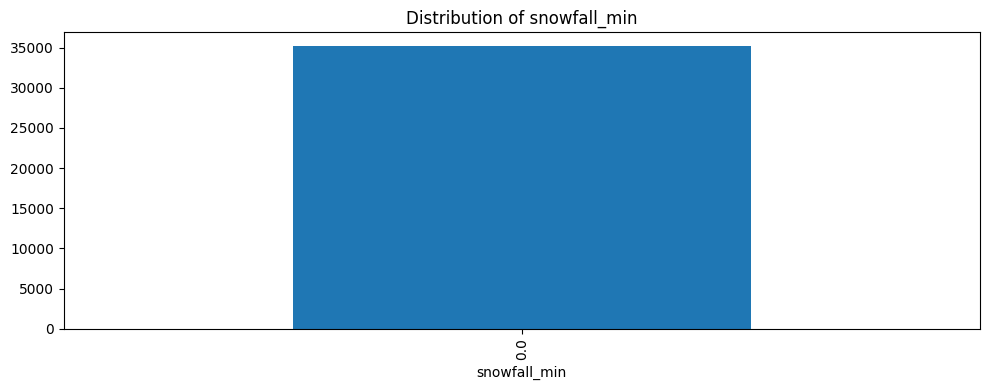

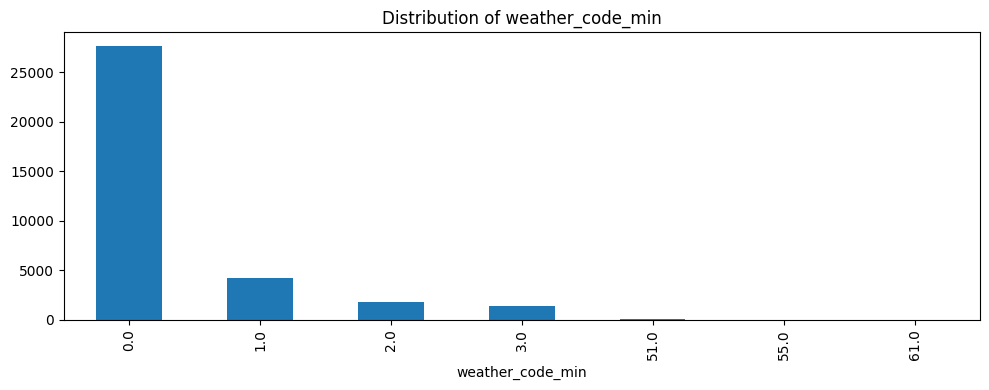

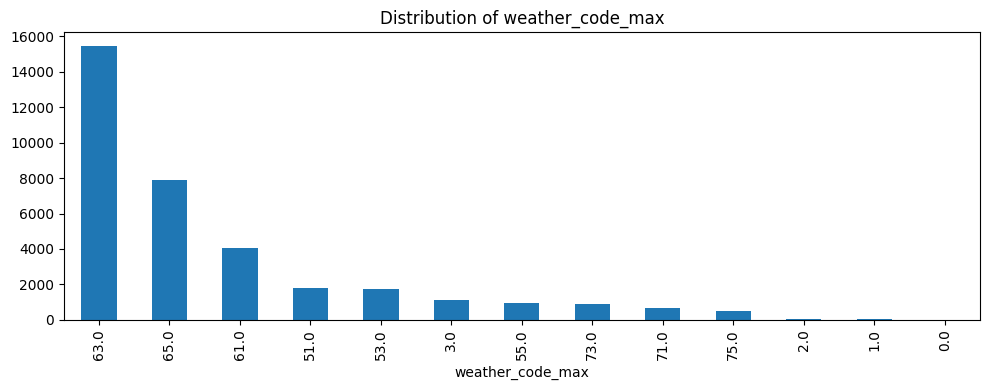

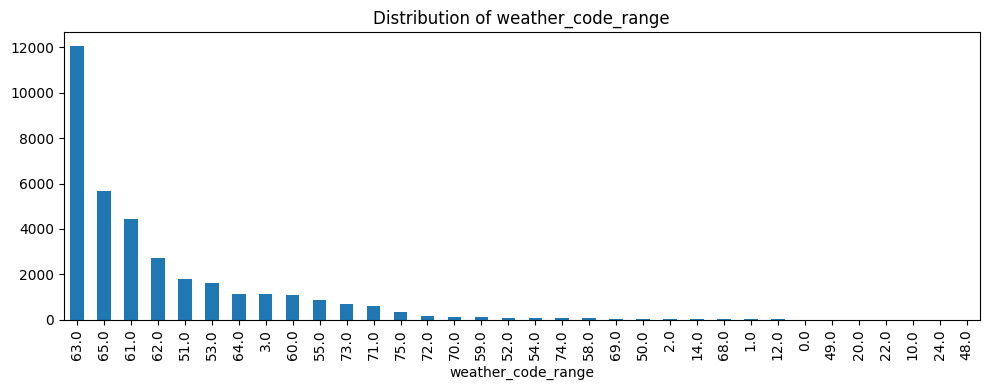

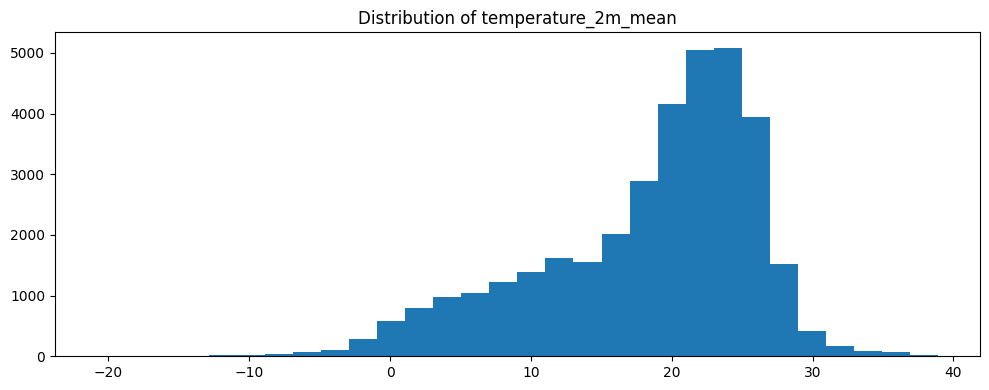

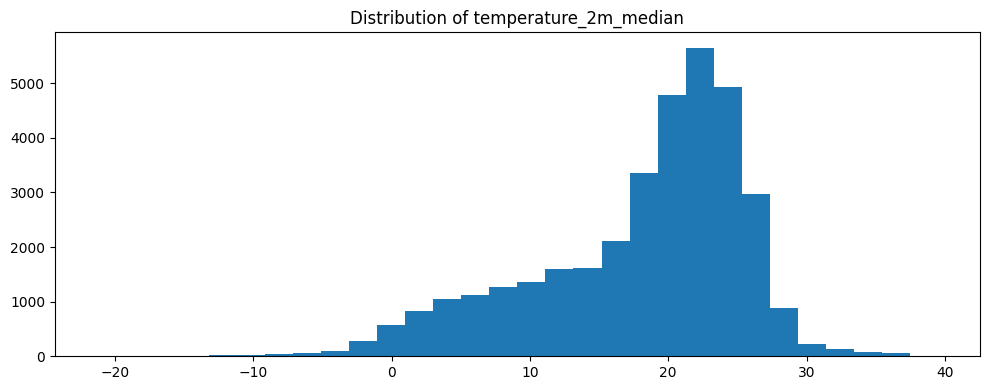

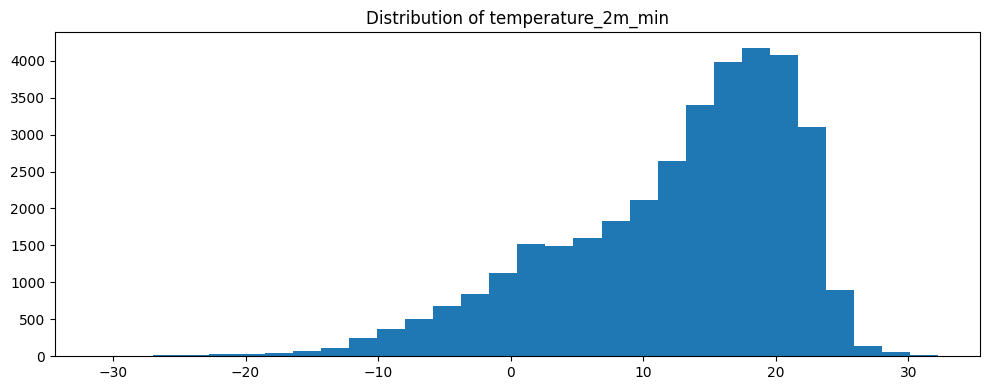

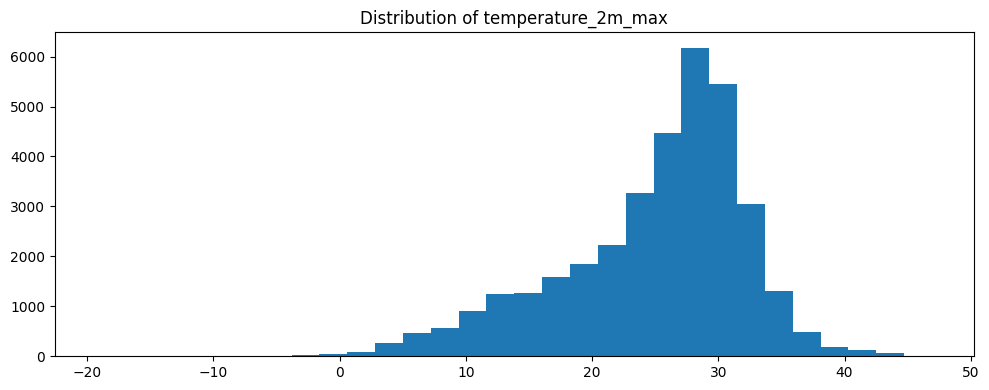

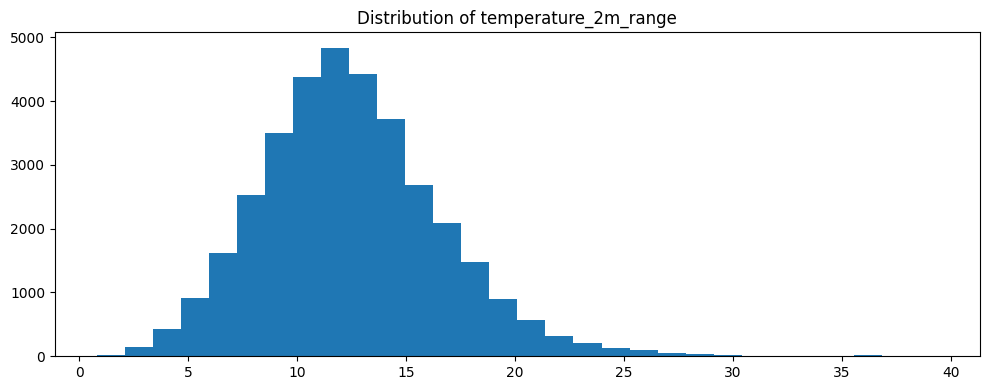

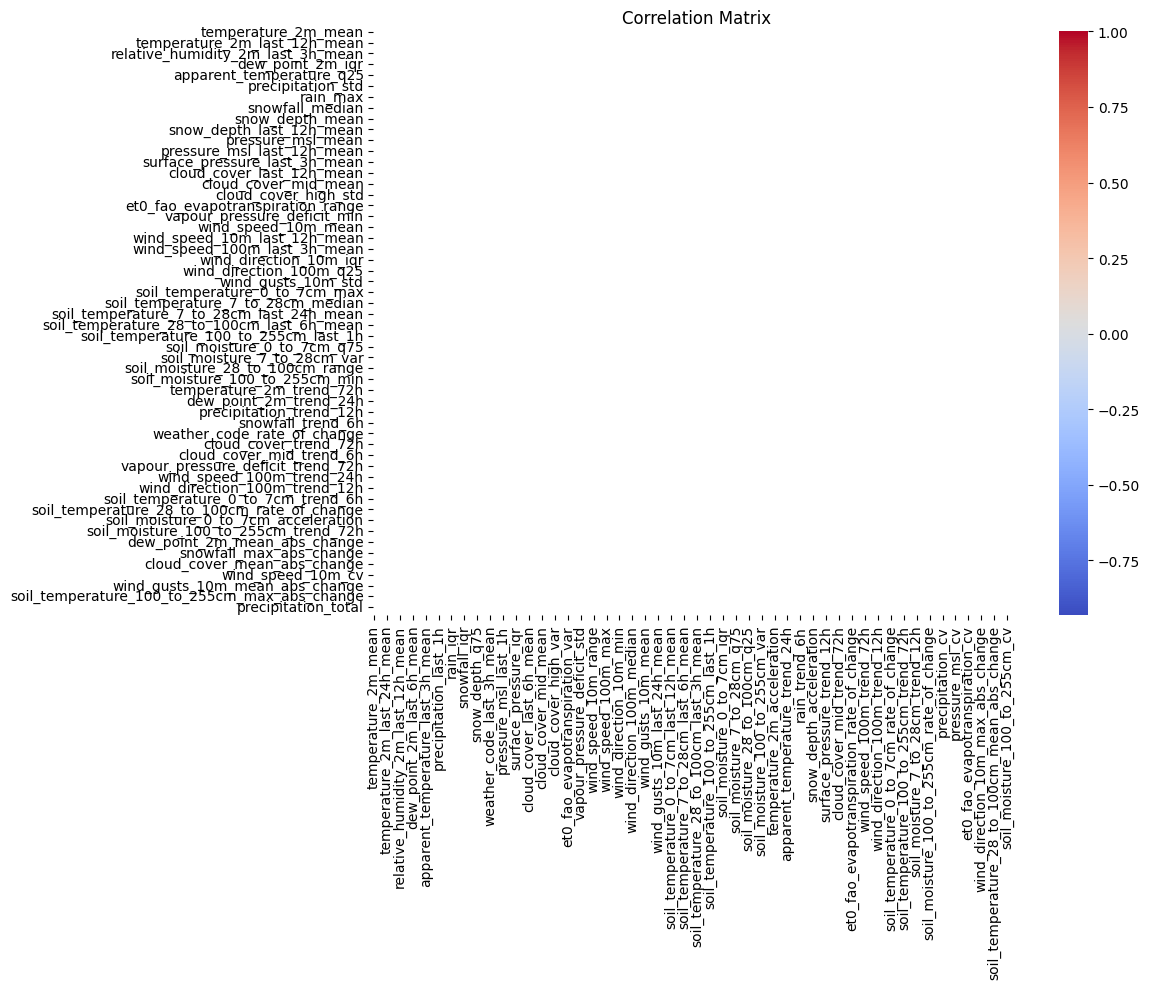

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Basic stats and information
print(without_prev.shape)
print(without_prev.info())
print(without_prev.describe().T)

# Check missing values
missing_values = without_prev.isnull().sum()
missing_percent = (missing_values / len(without_prev)) * 100
missing_data = pd.concat([missing_values, missing_percent], axis=1)
missing_data.columns = ['Missing Values', 'Percentage']
print(missing_data[missing_data['Missing Values'] > 0].sort_values('Percentage', ascending=False))

# Distribution of categorical variables
for col in categorical_cols[:5]:  # First 5 for brevity
    plt.figure(figsize=(10, 4))
    without_prev[col].value_counts().plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

# Distribution of numerical variables
for col in numerical_cols[:5]:  # First 5 for brevity
    plt.figure(figsize=(10, 4))
    plt.hist(without_prev[col].dropna(), bins=30)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

# Correlation heatmap for numerical features
corr_matrix = without_prev[numerical_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()



In [7]:
null_cols = ['snowfall_cv','snow_depth_cv','rain_cv','precipitation_cv']
without_prev.drop(columns=null_cols, inplace=True)

In [9]:
categorical_cols

NameError: name 'categorical_cols' is not defined

In [11]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import numpy as np

# Handle missing values
# For numerical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# For categorical features
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Now you can fit this preprocessor to your data
y = without_prev['extreme']
X = without_prev.copy()  # Assuming your target variable is not in this dataframe
X_processed = preprocessor.fit_transform(X)

# Convert to DataFrame for easier viewing
feature_names = (
    numerical_cols + 
    preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols).tolist()
)
X_processed_df = pd.DataFrame(X_processed, columns=feature_names)
print(X_processed_df.shape)
print(X_processed_df.head())

(35137, 5504)
   temperature_2m_mean  temperature_2m_median  temperature_2m_min  \
0            -0.290244              -0.307167           -0.045728   
1             0.323696               0.336805            0.426424   
2             0.252043               0.300847            0.668120   
3             0.413981               0.414147            0.400174   
4             0.146613               0.118639            0.078661   

   temperature_2m_max  temperature_2m_range  temperature_2m_std  \
0           -0.539383             -0.859262           -1.001928   
1            0.340896             -0.306611           -0.638649   
2           -0.221128             -1.820393           -1.729734   
3            0.268646             -0.378696           -0.240331   
4            0.152178              0.101870            0.359595   

   temperature_2m_var  temperature_2m_q25  temperature_2m_q75  \
0           -0.834583           -0.115127           -0.423018   
1           -0.620871            0.449

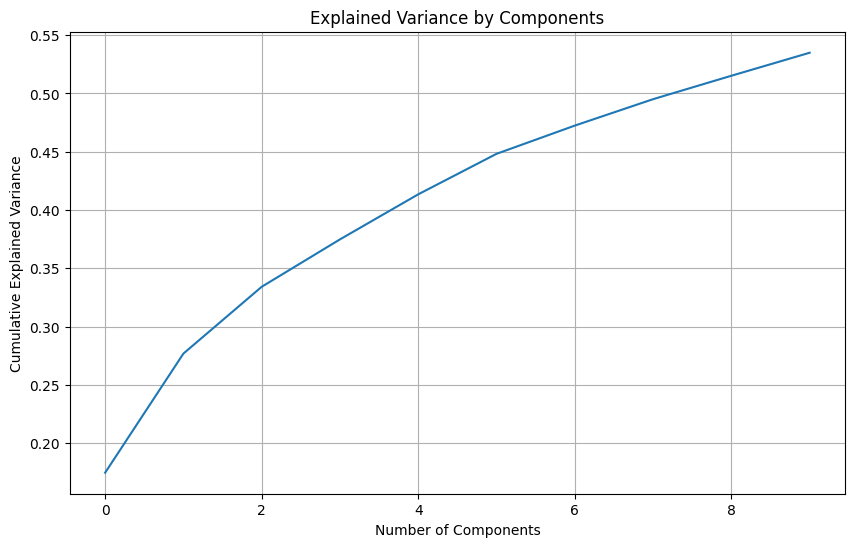

Number of components for 95% variance: 1


In [13]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# PCA for numerical features if you have many
pca = PCA(n_components=min(10, len(numerical_cols)))
X_numerical = preprocessor.named_transformers_['num'].fit_transform(X[numerical_cols])
X_pca = pca.fit_transform(X_numerical)

# Look at explained variance
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Components')
plt.grid(True)
plt.show()

# Determine optimal number of components (e.g., 95% variance)
n_components = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.75) + 1
print(f"Number of components for 95% variance: {n_components}")

# t-SNE for visualization (only if you have a target variable)
# Assuming you have a target variable 'y'
# tsne = TSNE(n_components=2, random_state=42)
# X_tsne = tsne.fit_transform(X_processed)
# plt.figure(figsize=(10, 8))
# sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette='viridis')
# plt.title('t-SNE Visualization')
# plt.show()

In [14]:
# Get the loadings of the first principal component
component_df = pd.DataFrame(
    pca.components_[0], 
    index=numerical_cols,
    columns=['PC1']
).sort_values('PC1', ascending=False)

# Show top 10 positive and negative contributors
print("Top positive contributors:")
print(component_df.head(10))
print("\nTop negative contributors:")
print(component_df.tail(10))

Top positive contributors:
                                                 PC1
soil_temperature_0_to_7cm_max               0.079702
soil_temperature_0_to_7cm_q75               0.079691
et0_fao_evapotranspiration_mean_abs_change  0.078940
et0_fao_evapotranspiration_mean             0.078007
et0_fao_evapotranspiration_q75              0.077787
soil_temperature_0_to_7cm_last_24h_mean     0.077667
soil_temperature_0_to_7cm_last_6h_mean      0.077591
soil_temperature_7_to_28cm_last_1h          0.077523
soil_temperature_0_to_7cm_last_12h_mean     0.077496
soil_temperature_7_to_28cm_last_3h_mean     0.077451

Top negative contributors:
                                            PC1
cloud_cover_mid_q75                   -0.061464
soil_moisture_7_to_28cm_max           -0.061713
soil_moisture_7_to_28cm_last_24h_mean -0.061742
soil_moisture_0_to_7cm_last_12h_mean  -0.062205
cloud_cover_mid_var                   -0.062356
soil_moisture_0_to_7cm_last_24h_mean  -0.062401
soil_moisture_7_to_28cm_la

In [18]:
# If you have a target variable 'y'
from scipy.stats import pearsonr

if 'extreme' in without_prev.columns:
    corr, p_value = pearsonr(X_pca[:, 0], without_prev['extreme'])
    print(f"Correlation of PC1 with target: {corr:.4f} (p-value: {p_value:.4e})")

Correlation of PC1 with target: -0.0474 (p-value: 6.0270e-19)


## Going without extracted features

In [19]:
import pandas as pd
without_extracted = pd.read_csv(r"merged_df.csv")

C:\Users\naman\AppData\Local\Temp\ipykernel_27016\3240101555.py:2: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  without_extracted = pd.read_csv(r"merged_df.csv")


In [20]:
without_extracted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35137 entries, 0 to 35136
Data columns (total 50 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   event_type                              35137 non-null  object 
 1   begin_date_time                         35137 non-null  object 
 2   cz_timezone                             35137 non-null  object 
 3   end_date_time                           35137 non-null  object 
 4   begin_lat                               35137 non-null  float64
 5   begin_lon                               35137 non-null  float64
 6   end_lat                                 35137 non-null  float64
 7   end_lon                                 35137 non-null  float64
 8   extreme                                 35137 non-null  int64  
 9   begin_date_utc                          35137 non-null  object 
 10  begin_time_utc                          35137 non-null  ob

In [ ]:
import re
import pandas as pd

def func(s):
    if not isinstance(s, str):
        return []  # Return empty list for non-string inputs
    
    dict_pattern = r'\{[^}]+\}'
    dict_matches = re.findall(dict_pattern, s)
    kv_pattern = r"'([^']+)':\s([^,}]+)"
    extracted_data = []

    for dict_str in dict_matches:  # Limit to first 10 dictionaries
        kv_matches = re.findall(kv_pattern, dict_str)
        extracted_dict = {key: value.strip() for key, value in kv_matches}
        extracted_data.append(extracted_dict)
    
    return extracted_data
result = []
# Read the CSV in chunks
chunk_size = 10000  # Adjust this based on your available memory
for chunk in pd.read_csv("final_ds_with_filenames.csv", chunksize=chunk_size):
    chunk["prev_72h_weather"] = chunk['prev_72h_weather'].apply(func)
    result.append(chunk)
    # Process or save the chunk here
    print("Processed chunk")
merged_df = pd.concat(result, ignore_index=True)
merged_df = merged_df.iloc[:7000, :]
print("All chunks processed")


C:\Users\naman\AppData\Local\Temp\ipykernel_28468\3454697256.py:10: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(r"merged_df.csv")
  0%|          | 0/31 [00:00<?, ?it/s]Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x000002381F5B9690>>
Traceback (most recent call last):
  File "C:\Users\naman\AppData\Roaming\Python\Python310\site-packages\ipykernel\ipkernel.py", line 788, in _clean_thread_parent_frames
    if phase != "start":
KeyboardInterrupt: 


C:\Users\naman\AppData\Local\Temp\ipykernel_1692\3932076591.py:2: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  merged_df = pd.read_csv("merged_df.csv")


In [1]:
import re
import pandas as pd
import pandas as pd
merged_df = pd.read_csv("merged_df.csv")
def func(s):
    if not isinstance(s, str):
        return []  # Return empty list for non-string inputs
    
    dict_pattern = r'\{[^}]+\}'
    dict_matches = re.findall(dict_pattern, s)
    kv_pattern = r"'([^']+)':\s([^,}]+)"
    extracted_data = []

    for dict_str in dict_matches:  # Limit to first 10 dictionaries
        kv_matches = re.findall(kv_pattern, dict_str)
        extracted_dict = {key: value.strip() for key, value in kv_matches}
        extracted_data.append(extracted_dict)
    
    return extracted_data
result = []
# Read the CSV in chunks
chunk_size = 10000  # Adjust this based on your available memory
for chunk in pd.read_csv("merged_df.csv", chunksize=chunk_size):
    chunk["prev_72h_weather"] = chunk['prev_72h_weather'].apply(func)
    result.append(chunk)
    # Process or save the chunk here
    print("Processed chunk")
merged_df = pd.concat(result, ignore_index=True)
print("All chunks processed")


C:\Users\naman\AppData\Local\Temp\ipykernel_24148\951648994.py:4: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  merged_df = pd.read_csv("merged_df.csv")


Processed chunk
Processed chunk
Processed chunk
Processed chunk
All chunks processed


In [3]:
merged_df["event_id"]

0            0
1            1
2            2
3            3
4            4
         ...  
35132    35132
35133    35133
35134    35134
35135    35135
35136    35136
Name: event_id, Length: 35137, dtype: int64

Sample of processed features:
{'event_id': 0, 'extreme': 0, 'prev_72h_temperature_2m_mean': np.float64(16.049860941039192), 'prev_72h_temperature_2m_std': np.float64(2.1489845776933216), 'prev_72h_temperature_2m_max': np.float64(20.932498931884766), 'prev_72h_temperature_2m_min': np.float64(12.032500267028809), 'prev_72h_temperature_2m_last': 12.032500267028809, 'prev_72h_relative_humidity_2m_mean': np.float64(85.18897480434842), 'prev_72h_relative_humidity_2m_std': np.float64(4.360897304853417), 'prev_72h_relative_humidity_2m_max': np.float64(91.0278091430664), 'prev_72h_relative_humidity_2m_min': np.float64(74.3496322631836), 'prev_72h_relative_humidity_2m_last': 89.04634857177734, 'prev_72h_dew_point_2m_mean': np.float64(13.533194608158535), 'prev_72h_dew_point_2m_std': np.float64(1.5598140695631602), 'prev_72h_dew_point_2m_max': np.float64(16.63249969482422), 'prev_72h_dew_point_2m_min': np.float64(10.282500267028809), 'prev_72h_dew_point_2m_last': 10.282500267028809, 'prev_72h_app

c:\Users\naman\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_stats_py.py:5405: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)



Top 20 features by correlation with extreme events:
                                    feature  correlation       p_value  \
20              prev_72h_precipitation_mean     0.098871  4.828582e-77   
25                       prev_72h_rain_mean     0.098453  2.095492e-76   
141  prev_72h_soil_moisture_28_to_100cm_std     0.094656  9.653737e-71   
92             prev_72h_wind_speed_100m_max     0.088191  1.290283e-61   
87              prev_72h_wind_speed_10m_max     0.085498  5.239069e-58   
94            prev_72h_wind_speed_100m_last     0.079183  5.522627e-50   
90            prev_72h_wind_speed_100m_mean     0.078785  1.685900e-49   
26                        prev_72h_rain_std     0.078549  3.252390e-49   
21               prev_72h_precipitation_std     0.078364  5.458672e-49   
48                prev_72h_pressure_msl_min    -0.078293  6.645741e-49   
85             prev_72h_wind_speed_10m_mean     0.077655  3.888702e-48   
89             prev_72h_wind_speed_10m_last     0.077380  8

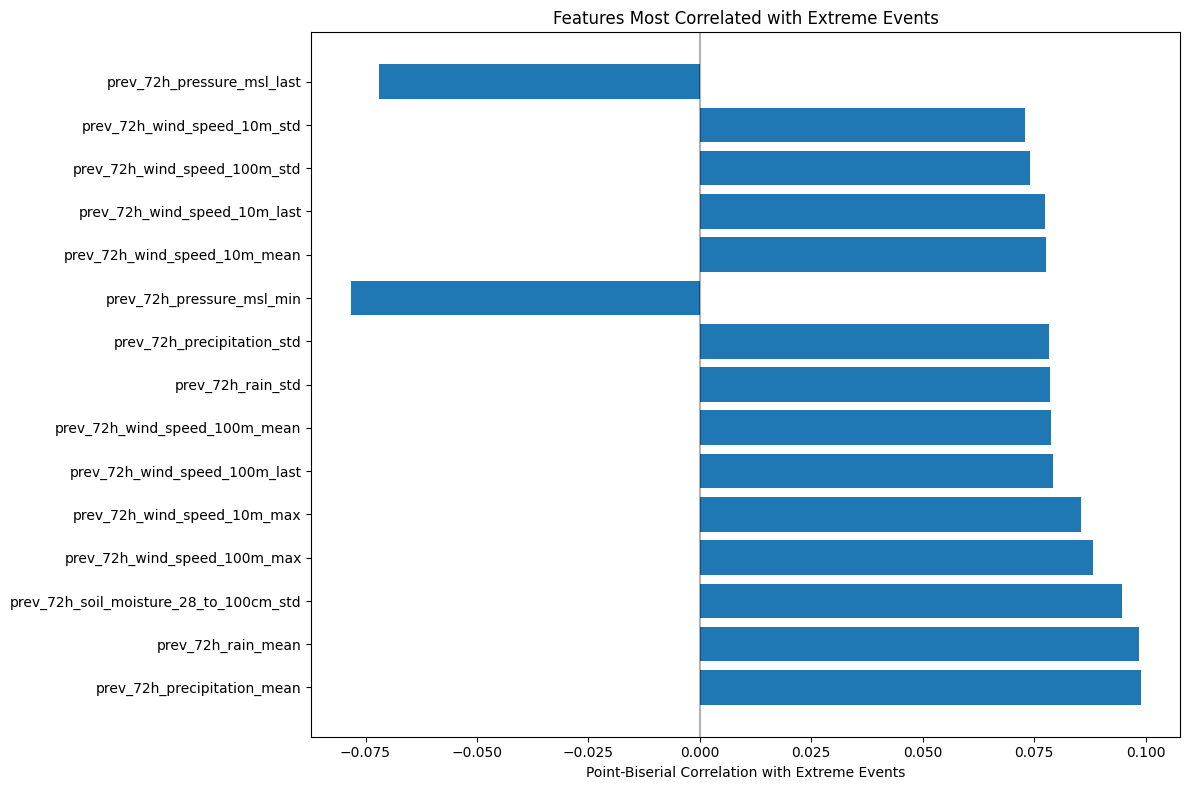

In [10]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr
without_extracted = merged_df.copy()
# Convert string representations of lists to actual lists if needed
time_series_columns = [col for col in without_extracted.columns if col.startswith('prev_72h_')]
time_series_columns.remove('prev_72h_weather')
# First, let's extract summary statistics from each time series
feature_stats = []

for idx, row in without_extracted.iterrows():
    row_stats = {'event_id': row['event_id'], 'extreme': row['extreme']}
    
    for col in time_series_columns:
        # Convert to list if it's still a string
        if isinstance(row[col], str):
            ts_data = ast.literal_eval(row[col])
        else:
            ts_data = row[col]
        ts_data = [float(val) for val in ts_data]
        # Calculate statistics
        row_stats[f"{col}_mean"] = np.mean(ts_data)
        row_stats[f"{col}_std"] = np.std(ts_data)
        row_stats[f"{col}_max"] = np.max(ts_data)
        row_stats[f"{col}_min"] = np.min(ts_data)
        row_stats[f"{col}_last"] = ts_data[-1] if len(ts_data) > 0 else np.nan
        
    feature_stats.append(row_stats)
    
    # Break after processing a few rows to check
    if idx == 0:
        print("Sample of processed features:")
        print(row_stats)
    
    # Status update for large datasets
    if idx % 5000 == 0 and idx > 0:
        print(f"Processed {idx} rows...")

# Create dataframe of features
stats_df = pd.DataFrame(feature_stats)

# Calculate point biserial correlation between each feature and extreme event indicator
correlations = {}
pvalues = {}

for col in stats_df.columns:
    if col not in ['event_id', 'extreme'] and not stats_df[col].isna().all():
        # Calculate point-biserial correlation (appropriate for binary target)
        corr, pval = pointbiserialr(stats_df['extreme'], stats_df[col])
        correlations[col] = corr
        pvalues[col] = pval

# Create a dataframe of correlations
corr_df = pd.DataFrame({
    'feature': correlations.keys(),
    'correlation': correlations.values(),
    'p_value': pvalues.values()
})

# Sort by absolute correlation
corr_df['abs_corr'] = corr_df['correlation'].abs()
corr_df = corr_df.sort_values('abs_corr', ascending=False)

# Display top correlations
print("\nTop 20 features by correlation with extreme events:")
print(corr_df.head(20))

# Plot top correlations
plt.figure(figsize=(12, 8))
top_features = corr_df.head(15)['feature'].values
corr_values = corr_df.head(15)['correlation'].values

plt.barh(top_features, corr_values)
plt.xlabel('Point-Biserial Correlation with Extreme Events')
plt.title('Features Most Correlated with Extreme Events')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()


Top 20 features by mutual information with extreme events:
                                        feature  mutual_info
92                 prev_72h_wind_speed_100m_max     0.012994
128  prev_72h_soil_temperature_100_to_255cm_min     0.012941
86                  prev_72h_wind_speed_10m_std     0.012569
95             prev_72h_wind_direction_10m_mean     0.012159
26                            prev_72h_rain_std     0.012070
25                           prev_72h_rain_mean     0.011981
21                   prev_72h_precipitation_std     0.011892
85                 prev_72h_wind_speed_10m_mean     0.011744
45                   prev_72h_pressure_msl_mean     0.011592
105                prev_72h_wind_gusts_10m_mean     0.011024
46                    prev_72h_pressure_msl_std     0.010908
91                 prev_72h_wind_speed_100m_std     0.010897
66                 prev_72h_cloud_cover_mid_std     0.010745
41                    prev_72h_weather_code_std     0.010562
97              prev_72h_

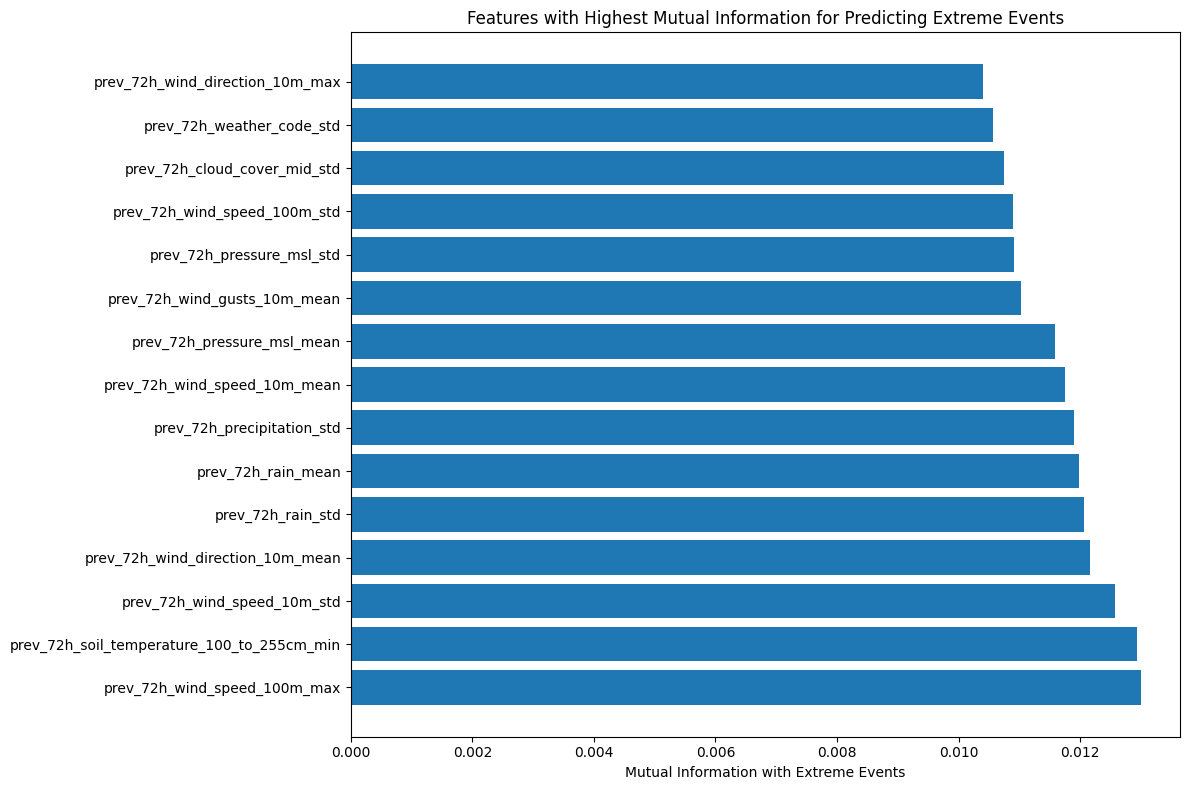

In [11]:
from sklearn.feature_selection import mutual_info_classif

# Calculate mutual information for classification
# This captures non-linear relationships
def calculate_mutual_info():
    # Take only numeric columns
    numeric_cols = stats_df.select_dtypes(include=np.number).columns
    numeric_cols = [col for col in numeric_cols if col not in ['event_id', 'extreme']]
    
    # Calculate mutual information
    X = stats_df[numeric_cols].fillna(0)  # Replace NaN with 0 for calculation
    y = stats_df['extreme']
    
    mi_values = mutual_info_classif(X, y, random_state=42)
    
    # Create dataframe of results
    mi_df = pd.DataFrame({
        'feature': numeric_cols,
        'mutual_info': mi_values
    }).sort_values('mutual_info', ascending=False)
    
    return mi_df

mi_df = calculate_mutual_info()

print("\nTop 20 features by mutual information with extreme events:")
print(mi_df.head(20))

# Plot top features by mutual information
plt.figure(figsize=(12, 8))
top_mi_features = mi_df.head(15)['feature'].values
mi_values = mi_df.head(15)['mutual_info'].values

plt.barh(top_mi_features, mi_values)
plt.xlabel('Mutual Information with Extreme Events')
plt.title('Features with Highest Mutual Information for Predicting Extreme Events')
plt.tight_layout()
plt.show()

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc
from sklearn.model_selection import cross_val_score

# Create a simple baseline model to assess predictability
def evaluate_baseline_predictability():
    # Prepare feature matrix from our statistics
    X = stats_df.drop(['event_id', 'extreme'], axis=1).fillna(0)
    y = stats_df['extreme']
    
    # Create a baseline random forest model
    model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    
    # Evaluate with cross-validation
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
    
    print("\nBaseline Model Predictability Assessment:")
    print(f"Cross-validated ROC AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    
    # 0.5 = random guessing, higher values indicate predictability
    if cv_scores.mean() > 0.7:
        print("Strong predictability detected (AUC > 0.7)")
    elif cv_scores.mean() > 0.6:
        print("Moderate predictability detected (0.6 < AUC < 0.7)")
    elif cv_scores.mean() > 0.55:
        print("Weak predictability detected (0.55 < AUC < 0.6)")
    else:
        print("Limited predictability detected (AUC < 0.55)")
    
    return cv_scores.mean()

baseline_auc = evaluate_baseline_predictability()


Baseline Model Predictability Assessment:
Cross-validated ROC AUC: 0.6624 ± 0.0315
Moderate predictability detected (0.6 < AUC < 0.7)


In [ ]:
# Evaluate if time order matters (genuine time series effect)
# or if just the feature values regardless of order are predictive
def test_time_order_importance():
    # Original features
    X = stats_df.drop(['event_id', 'extreme'], axis=1).fillna(0)
    y = stats_df['extreme']
    
    # Create a baseline model
    model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    original_score = cross_val_score(model, X, y, cv=5, scoring='roc_auc').mean()
    
    # Now randomly shuffle the time series and recompute features
    shuffled_stats = []
    
    for idx, row in without_extracted.iterrows():
        row_stats = {'event_id': row['event_id'], 'extreme': row['extreme']}
        
        for col in time_series_columns:
            # Convert to list if needed
            if isinstance(row[col], str):
                ts_data = ast.literal_eval(row[col])
            else:
                ts_data = row[col]
                
            # Shuffle the time series to destroy temporal patterns
            shuffled_ts = ts_data.copy()
            np.random.shuffle(shuffled_ts)
            
            # Calculate statistics on shuffled data
            row_stats[f"{col}_mean"] = np.mean(shuffled_ts)
            row_stats[f"{col}_std"] = np.std(shuffled_ts)
            row_stats[f"{col}_max"] = np.max(shuffled_ts)
            row_stats[f"{col}_min"] = np.min(shuffled_ts)
            row_stats[f"{col}_last"] = shuffled_ts[-1] if len(shuffled_ts) > 0 else np.nan
            
        shuffled_stats.append(row_stats)
        
        # Status update
        if idx % 5000 == 0 and idx > 0:
            print(f"Processed {idx} shuffled rows...")
    
    # Create dataframe of shuffled features
    shuffled_df = pd.DataFrame(shuffled_stats)
    
    # Train model on shuffled features
    X_shuffled = shuffled_df.drop(['event_id', 'extreme'], axis=1).fillna(0)
    y_shuffled = shuffled_df['extreme']
    
    shuffled_score = cross_val_score(model, X_shuffled, y_shuffled, cv=5, scoring='roc_auc').mean()
    
    print("\nTime Order Importance Analysis:")
    print(f"Original data ROC AUC: {original_score:.4f}")
    print(f"Shuffled time series ROC AUC: {shuffled_score:.4f}")
    
    if original_score - shuffled_score > 0.05:
        print("Time order is IMPORTANT - temporal patterns are predictive")
    else:
        print("Time order has LIMITED IMPORTANCE - statistical features may be sufficient")
    
    return original_score - shuffled_score

# You can uncomment this to run the time order importance test
# time_importance = test_time_order_importance()

['prev_72h_temperature_2m',
 'prev_72h_relative_humidity_2m',
 'prev_72h_dew_point_2m',
 'prev_72h_apparent_temperature',
 'prev_72h_precipitation',
 'prev_72h_rain',
 'prev_72h_snowfall',
 'prev_72h_snow_depth',
 'prev_72h_weather_code',
 'prev_72h_pressure_msl',
 'prev_72h_surface_pressure',
 'prev_72h_cloud_cover',
 'prev_72h_cloud_cover_low',
 'prev_72h_cloud_cover_mid',
 'prev_72h_cloud_cover_high',
 'prev_72h_et0_fao_evapotranspiration',
 'prev_72h_vapour_pressure_deficit',
 'prev_72h_wind_speed_10m',
 'prev_72h_wind_speed_100m',
 'prev_72h_wind_direction_10m',
 'prev_72h_wind_direction_100m',
 'prev_72h_wind_gusts_10m',
 'prev_72h_soil_temperature_0_to_7cm',
 'prev_72h_soil_temperature_7_to_28cm',
 'prev_72h_soil_temperature_28_to_100cm',
 'prev_72h_soil_temperature_100_to_255cm',
 'prev_72h_soil_moisture_0_to_7cm',
 'prev_72h_soil_moisture_7_to_28cm',
 'prev_72h_soil_moisture_28_to_100cm',
 'prev_72h_soil_moisture_100_to_255cm']